# NLP2 LoRA Training-Size Ablation
# Goal:
# Test whether increasing the amount of cleaner terminology-focused training data
# improves LoRA adaptation performance.
#
# RQ2 link: training-data modification / amount of terminology-focused supervision.
## RQ3 link: LoRA model adaptation.

In [1]:
!pip install -q transformers datasets accelerate peft trl sacrebleu sentencepiece protobuf
!pip uninstall -y torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 54.3 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [2]:
import os
import ast
import json
import gc
import random
import pandas as pd
import torch
import sacrebleu

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [3]:
from google.colab import files

uploaded = files.upload()
print(uploaded.keys())

Saving nlp2_full_dataframe_all_experiments_500.csv to nlp2_full_dataframe_all_experiments_500.csv
dict_keys(['nlp2_full_dataframe_all_experiments_500.csv'])


In [4]:
csv_name = list(uploaded.keys())[0]

df = pd.read_csv(csv_name)

print(df.shape)
print(df.columns)
df.head()

(500, 28)
Index(['source', 'reference', 'terms', 'base_basic', 'base_strong',
       'lora_no_term', 'lora_basic', 'lora_basic_cleaned', 'terms_dict',
       'qwen3b_basic', 'qwen3b_strong', 'qwen3b_no_term',
       'qwen3b_selected_source', 'qwen3b_selected',
       'qwen3b_selected_term_coverage', 'random_terms_dict', 'qwen3b_random',
       'selected_missing_terms', 'num_missing_selected',
       'qwen3b_selected_repaired', 'repaired_missing_terms',
       'num_missing_repaired', 'qwen3b_definition_prompt',
       'lora_cleaned_missing_terms', 'num_missing_lora_cleaned',
       'lora_basic_cleaned_repaired', 'lora_repaired_missing_terms',
       'num_missing_lora_repaired'],
      dtype='object')


,source,reference,terms,base_basic,base_strong,lora_no_term,lora_basic,lora_basic_cleaned,terms_dict,qwen3b_basic,...,num_missing_selected,qwen3b_selected_repaired,repaired_missing_terms,num_missing_repaired,qwen3b_definition_prompt,lora_cleaned_missing_terms,num_missing_lora_cleaned,lora_basic_cleaned_repaired,lora_repaired_missing_terms,num_missing_lora_repaired
0,This service describes the deployed (run-time)...,Dieser Service beschreibt den implementierten ...,"{'design': 'Entwurf', 'state': 'Zustand'}",Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführt- oder...,Dieses Service beschreibt den ausgeführt- oder...,Dieses Service beschreibt den ausgeführt- oder...,"{'design': 'Entwurf', 'state': 'Zustand'}",Dieser Service beschreibt den ausgeführten (la...,...,0,Dieser Service beschreibt den ausgeführten (La...,{},0,Dieser Service beschreibt den ausgeführten (La...,{},0,Dieses Service beschreibt den ausgeführt- oder...,{},0
1,Request a checkup to perform a health diagnost...,"Fordern Sie eine Kontrolle an, um eine Fehlerd...",{'check': 'Kontrolle'},"Kontrolliere bitte einen Überwachungsbesuch, u...",Kontrollieren Sie bitte einen Check auf die Du...,Gerüste ein Checkup um einen Gesundheitsdiagno...,Kontrollieren Sie Ihre Datenflussanalyse durch...,Kontrollieren Sie Ihre Datenflussanalyse durch...,{'check': 'Kontrolle'},"Eine Kontrolle anfordern, um eine gesundheitsd...",...,0,Kontrolle für eine Gesundheitsdiagnostik durch...,{},0,Eine Kontrolle für eine Gesundheitsdiagnostik ...,{},0,Kontrollieren Sie Ihre Datenflussanalyse durch...,{},0
2,The data product is still available in the pro...,Das Datenprodukt ist weiterhin in der Datenpro...,{'provider': 'Provider'},Der Datenprodukt ist noch im Angebot des Provi...,Der Datenprodukt ist immer noch im Liste der D...,Der Datenprodukt ist noch im Provider-Liste ve...,Der Datenprodukt ist noch im Provider-Liste ve...,Der Datenprodukt ist noch im Provider-Liste ve...,{'provider': 'Provider'},Der Datenprodukt ist im Datenproduktverzeichni...,...,0,Der Datenprodukt ist im Datenproduktverzeichni...,{},0,Das Datenprodukt ist im Provider-Datenproduktv...,{},0,Der Datenprodukt ist noch im Provider-Liste ve...,{},0
3,This availability match percentage is calculat...,Diese prozentuale Verfügbarkeitsübereinstimmun...,{'percentage': 'prozentual'},Diese Verfügbarkeits-Match-Prozentsatz wird au...,Diese Verfügbarkeitsübereinstimmung ist basier...,Diese Verfügbarkeits-Match-Prozentsatz wird au...,Dieses Verfügbarkeitsmatch-Prozentsatz wird au...,Dieses Verfügbarkeitsmatch-Prozentsatz wird au...,{'percentage': 'prozentual'},Diese prozentuale Verfügbarkeitsmatchquote wir...,...,0,Diese prozentuale Verfügbarkeitsmatchquote wir...,{},0,Diese prozentuale Verfügbarkeitsmatchquote wir...,{'percentage': 'prozentual'},1,Dieser Verfügbarkeitsmatch-prozentuale Wert wi...,{},0
4,Open the consumption model containing the meas...,Öffnen Sie das Verbrauchsmodell mit den Kennza...,{'consumption model': 'Verbrauchsmodell'},"Öffne das Verbrauchsmodell, das die Maßnahmen ...","Verwenden Sie den Verbrauchsmodell, der die Ma...",Öffnen Sie den Konsummodellinhalt mit den Maße...,Gerne! Hier ist die deutsche Übersetzung:\n\nÖ...,"Öffnen Sie das Verbrauchsmodell, das die Maße ...",{'consumption model': 'Verbrauchsmodell'},"Öffnen Sie das Verbrauchsmodell, das die Maßna...",...,0,"Verfügen Sie über das Verbrauchsmodell, das di...",{},0,"Öffne das Verbrauchsmodell, das die zu berücks...",{},0,"Öffnen Sie das Verbrauchsmodell, das die Maße ...",{},0


In [5]:
def parse_terms(x):
    if isinstance(x, dict):
        return x

    if pd.isna(x):
        return {}

    if isinstance(x, str):
        try:
            value = ast.literal_eval(x)
            if isinstance(value, dict):
                return value
        except Exception:
            pass

        try:
            value = json.loads(x)
            if isinstance(value, dict):
                return value
        except Exception:
            pass

    return {}


if "terms_dict" in df.columns:
    df["terms_dict"] = df["terms_dict"].apply(parse_terms)
else:
    df["terms_dict"] = df["terms"].apply(parse_terms)

print(type(df.loc[0, "terms_dict"]))
df[["source", "reference", "terms_dict"]].head()

<class 'dict'>


,source,reference,terms_dict
0,This service describes the deployed (run-time)...,Dieser Service beschreibt den implementierten ...,"{'design': 'Entwurf', 'state': 'Zustand'}"
1,Request a checkup to perform a health diagnost...,"Fordern Sie eine Kontrolle an, um eine Fehlerd...",{'check': 'Kontrolle'}
2,The data product is still available in the pro...,Das Datenprodukt ist weiterhin in der Datenpro...,{'provider': 'Provider'}
3,This availability match percentage is calculat...,Diese prozentuale Verfügbarkeitsübereinstimmun...,{'percentage': 'prozentual'}
4,Open the consumption model containing the meas...,Öffnen Sie das Verbrauchsmodell mit den Kennza...,{'consumption model': 'Verbrauchsmodell'}


In [6]:
random.seed(42)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df = df.iloc[:400].copy()
eval_df = df.iloc[400:500].copy()

print("Train:", train_df.shape)
print("Eval:", eval_df.shape)

Train: (400, 28)
Eval: (100, 28)


In [7]:
def terms_to_lines(terms_dict):
    lines = []

    for source_term, target_term in terms_dict.items():
        lines.append(f"{source_term} -> {target_term}")

    return "\n".join(lines)


def make_basic_training_prompt(source, terms_dict):
    terms_text = terms_to_lines(terms_dict)

    prompt = f"""Translate the English sentence into German.
Use the provided terminology when relevant.
Return only the German translation.

English sentence:
{source}

Terminology:
{terms_text}

German translation:"""

    return prompt


def make_strong_training_prompt(source, terms_dict):
    terms_text = terms_to_lines(terms_dict)

    prompt = f"""Translate the English sentence into German.
You must use the exact German target term whenever the corresponding English source term appears.
Return only the German translation. Do not add explanations or introductions.

English sentence:
{source}

Terminology:
{terms_text}

German translation:"""

    return prompt

In [8]:
def build_lora_v2_training_rows(dataframe):
    rows = []

    for _, row in dataframe.iterrows():
        source = row["source"]
        reference = str(row["reference"]).strip()
        terms_dict = row["terms_dict"]

        basic_prompt = make_basic_training_prompt(source, terms_dict)
        strong_prompt = make_strong_training_prompt(source, terms_dict)

        rows.append({
            "prompt": basic_prompt,
            "completion": reference,
            "prompt_type": "basic"
        })

        rows.append({
            "prompt": strong_prompt,
            "completion": reference,
            "prompt_type": "strong"
        })

    return pd.DataFrame(rows)


test_sft_df = build_lora_v2_training_rows(train_df.iloc[:2])
print(test_sft_df.shape)
print(test_sft_df.iloc[0]["prompt"])
print("\nCOMPLETION:")
print(test_sft_df.iloc[0]["completion"])

(4, 3)
Translate the English sentence into German.
Use the provided terminology when relevant.
Return only the German translation.

English sentence:
Select the report category that you would like to extend.

Terminology:
category -> Kategorie

German translation:

COMPLETION:
Wählen Sie die Meldekategorie aus, die Sie erweitern möchten.


In [9]:
base_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded


In [10]:
def format_sft_example(example):
    messages = [
        {"role": "user", "content": example["prompt"]},
        {"role": "assistant", "content": example["completion"]}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    return {"text": text}

In [12]:
def make_basic_eval_prompt(source, terms_dict):
    terms_text = terms_to_lines(terms_dict)

    prompt = f"""Translate the English sentence into German.
Use the provided terminology when relevant.
Return only the German translation. Do not add explanations or introductions.

English sentence:
{source}

Terminology:
{terms_text}

German translation:"""

    return prompt

In [13]:
def generate_outputs(model, tokenizer, dataframe, prompt_function, batch_size=4, max_new_tokens=160):
    outputs = []

    model.eval()

    for start in range(0, len(dataframe), batch_size):
        batch = dataframe.iloc[start:start + batch_size]
        prompts = []

        for _, row in batch.iterrows():
            prompt = prompt_function(row["source"], row["terms_dict"])

            messages = [
                {"role": "user", "content": prompt}
            ]

            chat_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            prompts.append(chat_text)

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(model.device)

        with torch.no_grad():
            generated = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        for i in range(len(batch)):
            input_length = inputs["input_ids"][i].shape[0]
            new_tokens = generated[i][input_length:]
            text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
            outputs.append(text)

        print(f"Generated {len(outputs)} / {len(dataframe)}")

    return outputs

In [14]:
def compute_bleu(outputs, references):
    bleu = sacrebleu.corpus_bleu(
        outputs,
        [references]
    )
    return bleu.score


def compute_term_accuracy(outputs, terms_list):
    total_terms = 0
    matched_terms = 0

    for output, terms_dict in zip(outputs, terms_list):
        output_lower = str(output).lower()

        for source_term, target_term in terms_dict.items():
            total_terms += 1

            if str(target_term).lower() in output_lower:
                matched_terms += 1

    if total_terms == 0:
        return 0

    return matched_terms / total_terms


def has_boilerplate(text):
    text_lower = str(text).lower()

    patterns = [
        "gerne",
        "hier ist",
        "übersetzung",
        "deutsche übersetzung",
        "die deutsche übersetzung",
        "translation"
    ]

    for pattern in patterns:
        if pattern in text_lower:
            return True

    return False

In [15]:
def train_lora_for_size(size, num_epochs=1):
    print("=" * 80)
    print(f"Training LoRA adapter with {size} source examples")
    print("=" * 80)

    gc.collect()
    torch.cuda.empty_cache()

    subset_df = train_df.iloc[:size].copy()
    subset_sft_df = build_lora_v2_training_rows(subset_df)

    print("Source examples:", len(subset_df))
    print("SFT rows:", len(subset_sft_df))

    subset_dataset = Dataset.from_pandas(subset_sft_df)
    subset_dataset = subset_dataset.map(format_sft_example)

    base_model_for_size = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16,
        device_map="auto"
    )

    lora_config_for_size = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )

    model_for_size = get_peft_model(base_model_for_size, lora_config_for_size)
    model_for_size.print_trainable_parameters()

    output_dir = f"checkpoints/lora_v2_ablation_{size}"

    training_args = SFTConfig(
        output_dir=output_dir,
        dataset_text_field="text",
        max_length=512,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        learning_rate=1e-4,
        num_train_epochs=num_epochs,
        logging_steps=10,
        save_steps=100,
        save_total_limit=1,
        fp16=True,
        report_to="none"
    )

    trainer = SFTTrainer(
        model=model_for_size,
        args=training_args,
        train_dataset=subset_dataset,
        processing_class=tokenizer
    )

    trainer.train()

    adapter_dir = f"lora_v2_ablation_{size}_adapter"
    model_for_size.save_pretrained(adapter_dir)

    print("Saved adapter:", adapter_dir)

    return model_for_size, adapter_dir

In [16]:
def evaluate_lora_size(model_for_size, size):
    output_col = f"lora_v2_ablation_{size}_basic"

    eval_df[output_col] = generate_outputs(
        model_for_size,
        tokenizer,
        eval_df,
        make_basic_eval_prompt,
        batch_size=4
    )

    bleu = compute_bleu(
        eval_df[output_col].tolist(),
        eval_df["reference"].tolist()
    )

    term_acc = compute_term_accuracy(
        eval_df[output_col].tolist(),
        eval_df["terms_dict"].tolist()
    )

    boilerplate_count = eval_df[output_col].apply(has_boilerplate).sum()

    result = {
        "train_source_examples": size,
        "sft_rows": size * 2,
        "method": f"LoRA v2 basic ({size})",
        "BLEU": bleu,
        "term_accuracy": term_acc,
        "boilerplate_count": boilerplate_count
    }

    return result

In [17]:
ablation_sizes = [50, 100, 200]
ablation_results = []

for size in ablation_sizes:
    model_for_size, adapter_dir = train_lora_for_size(size, num_epochs=1)

    result = evaluate_lora_size(model_for_size, size)
    ablation_results.append(result)

    print("Result:")
    print(result)

    partial_df = pd.DataFrame(ablation_results)
    partial_df.to_csv("nlp2_lora_v2_training_size_ablation_partial.csv", index=False)

    del model_for_size
    gc.collect()
    torch.cuda.empty_cache()

ablation_partial_df = pd.DataFrame(ablation_results)
ablation_partial_df

Training LoRA adapter with 50 source examples
Source examples: 50
SFT rows: 100


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

Tokenizing train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.379736
20,1.016990


Saved adapter: lora_v2_ablation_200_adapter
Generated 4 / 100
Generated 8 / 100
Generated 12 / 100
Generated 16 / 100
Generated 20 / 100
Generated 24 / 100
Generated 28 / 100
Generated 32 / 100
Generated 36 / 100
Generated 40 / 100
Generated 44 / 100
Generated 48 / 100
Generated 52 / 100
Generated 56 / 100
Generated 60 / 100
Generated 64 / 100
Generated 68 / 100
Generated 72 / 100
Generated 76 / 100
Generated 80 / 100
Generated 84 / 100
Generated 88 / 100
Generated 92 / 100
Generated 96 / 100
Generated 100 / 100
Result:
{'train_source_examples': 200, 'sft_rows': 400, 'method': 'LoRA v2 basic (200)', 'BLEU': 20.726241444960653, 'term_accuracy': 0.6727272727272727, 'boilerplate_count': np.int64(0)}


,train_source_examples,sft_rows,method,BLEU,term_accuracy,boilerplate_count
0,50,100,LoRA v2 basic (50),19.351534,0.727273,0
1,100,200,LoRA v2 basic (100),19.854921,0.700000,0
2,200,400,LoRA v2 basic (200),20.726241,0.672727,0


In [18]:
ablation_full_df = pd.DataFrame(ablation_results)

existing_400_basic = {
    "train_source_examples": 400,
    "sft_rows": 800,
    "method": "LoRA v2 basic (400)",
    "BLEU": 23.236286,
    "term_accuracy": 0.772727,
    "boilerplate_count": 0
}

existing_400_repair = {
    "train_source_examples": 400,
    "sft_rows": 800,
    "method": "LoRA v2 basic + repair (400)",
    "BLEU": 24.139542,
    "term_accuracy": 0.881818,
    "boilerplate_count": 0
}

ablation_full_df = pd.concat(
    [
        ablation_full_df,
        pd.DataFrame([existing_400_basic, existing_400_repair])
    ],
    ignore_index=True
)

ablation_full_df

,train_source_examples,sft_rows,method,BLEU,term_accuracy,boilerplate_count
0,50,100,LoRA v2 basic (50),19.351534,0.727273,0
1,100,200,LoRA v2 basic (100),19.854921,0.700000,0
2,200,400,LoRA v2 basic (200),20.726241,0.672727,0
3,400,800,LoRA v2 basic (400),23.236286,0.772727,0
4,400,800,LoRA v2 basic + repair (400),24.139542,0.881818,0


In [19]:
eval_df.to_csv("nlp2_lora_v2_training_size_ablation_outputs_100.csv", index=False)
ablation_full_df.to_csv("nlp2_lora_v2_training_size_ablation_metrics_100.csv", index=False)

!zip nlp2_lora_v2_training_size_ablation_experiment.zip \
nlp2_lora_v2_training_size_ablation_outputs_100.csv \
nlp2_lora_v2_training_size_ablation_metrics_100.csv \
nlp2_lora_v2_training_size_ablation_partial.csv

from google.colab import files
files.download("nlp2_lora_v2_training_size_ablation_experiment.zip")

  adding: nlp2_lora_v2_training_size_ablation_outputs_100.csv (deflated 83%)
  adding: nlp2_lora_v2_training_size_ablation_metrics_100.csv (deflated 44%)
  adding: nlp2_lora_v2_training_size_ablation_partial.csv (deflated 35%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

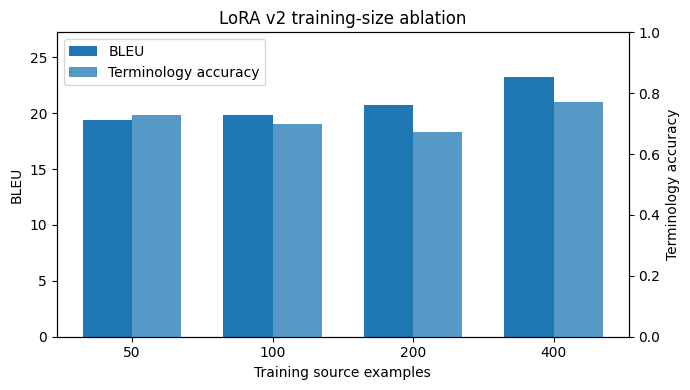

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

plot_df = ablation_full_df[
    ablation_full_df["method"].str.contains("basic \\(", regex=True)
].copy()

plot_df = plot_df.sort_values("train_source_examples")

x = np.arange(len(plot_df))
width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.bar(x - width/2, plot_df["BLEU"], width, label="BLEU")
ax1.set_ylabel("BLEU")
ax1.set_ylim(0, max(plot_df["BLEU"]) + 4)

ax2 = ax1.twinx()
ax2.bar(x + width/2, plot_df["term_accuracy"], width, label="Terminology accuracy", alpha=0.75)
ax2.set_ylabel("Terminology accuracy")
ax2.set_ylim(0, 1)

ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["train_source_examples"].astype(str))
ax1.set_xlabel("Training source examples")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.title("LoRA v2 training-size ablation")
plt.tight_layout()
plt.savefig("nlp2_lora_v2_training_size_ablation.png", dpi=300)
plt.show()

files.download("nlp2_lora_v2_training_size_ablation.png")

In [21]:
# Retrain the 400-example LoRA adapter

model_400, adapter_400_dir = train_lora_for_size(400, num_epochs=1)

result_400 = evaluate_lora_size(model_400, 400)

print("Retrained 400-example result:")
print(result_400)

Training LoRA adapter with 400 source examples
Source examples: 400
SFT rows: 800


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815


Adding EOS to train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.349840
20,1.080252
30,0.935291
40,0.938130
50,0.891660


Saved adapter: lora_v2_ablation_400_adapter
Generated 4 / 100
Generated 8 / 100
Generated 12 / 100
Generated 16 / 100
Generated 20 / 100
Generated 24 / 100
Generated 28 / 100
Generated 32 / 100
Generated 36 / 100
Generated 40 / 100
Generated 44 / 100
Generated 48 / 100
Generated 52 / 100
Generated 56 / 100
Generated 60 / 100
Generated 64 / 100
Generated 68 / 100
Generated 72 / 100
Generated 76 / 100
Generated 80 / 100
Generated 84 / 100
Generated 88 / 100
Generated 92 / 100
Generated 96 / 100
Generated 100 / 100
Retrained 400-example result:
{'train_source_examples': 400, 'sft_rows': 800, 'method': 'LoRA v2 basic (400)', 'BLEU': 23.235133205442157, 'term_accuracy': 0.7818181818181819, 'boilerplate_count': np.int64(0)}


In [22]:
ablation_full_df = pd.DataFrame(ablation_results)

ablation_full_df = pd.concat(
    [
        ablation_full_df,
        pd.DataFrame([result_400])
    ],
    ignore_index=True
)

ablation_full_df

,train_source_examples,sft_rows,method,BLEU,term_accuracy,boilerplate_count
0,50,100,LoRA v2 basic (50),19.351534,0.727273,0
1,100,200,LoRA v2 basic (100),19.854921,0.700000,0
2,200,400,LoRA v2 basic (200),20.726241,0.672727,0
3,400,800,LoRA v2 basic (400),23.235133,0.781818,0


In [23]:
def get_missing_terms(output, terms_dict):
    output_lower = str(output).lower()
    missing = {}

    for source_term, target_term in terms_dict.items():
        if str(target_term).lower() not in output_lower:
            missing[source_term] = target_term

    return missing


def make_repair_prompt(source, current_translation, missing_terms):
    term_lines = []

    for source_term, target_term in missing_terms.items():
        term_lines.append(f"{source_term} -> {target_term}")

    missing_text = "\n".join(term_lines)

    prompt = f"""You are revising a German machine translation.

The current translation is mostly correct, but it is missing required terminology.
Revise the translation so that it includes the required German terms.
Keep the meaning of the original English sentence.
Return only the revised German translation.
Do not add explanations or introductions.

English sentence:
{source}

Current German translation:
{current_translation}

Required missing terminology:
{missing_text}

Revised German translation:"""

    return prompt


eval_df["lora_v2_ablation_400_missing_terms"] = eval_df.apply(
    lambda row: get_missing_terms(row["lora_v2_ablation_400_basic"], row["terms_dict"]),
    axis=1
)

eval_df["num_missing_lora_v2_ablation_400"] = eval_df["lora_v2_ablation_400_missing_terms"].apply(len)

print("Before repair:")
print(eval_df["num_missing_lora_v2_ablation_400"].value_counts().sort_index())
print("Rows needing repair:", (eval_df["num_missing_lora_v2_ablation_400"] > 0).sum())

Before repair:
num_missing_lora_v2_ablation_400
0    77
1    22
2     1
Name: count, dtype: int64
Rows needing repair: 23


In [24]:
def generate_repairs_for_400(model_for_size, dataframe, batch_size=4, max_new_tokens=160):
    repaired_outputs = dataframe["lora_v2_ablation_400_basic"].tolist()

    repair_indices = dataframe.index[dataframe["num_missing_lora_v2_ablation_400"] > 0].tolist()
    print("Repairing", len(repair_indices), "outputs")

    index_to_position = {}
    for position, index_label in enumerate(dataframe.index):
        index_to_position[index_label] = position

    model_for_size.eval()

    for start in range(0, len(repair_indices), batch_size):
        batch_indices = repair_indices[start:start + batch_size]
        prompts = []

        for idx in batch_indices:
            row = dataframe.loc[idx]
            prompt = make_repair_prompt(
                row["source"],
                row["lora_v2_ablation_400_basic"],
                row["lora_v2_ablation_400_missing_terms"]
            )

            messages = [
                {"role": "user", "content": prompt}
            ]

            chat_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            prompts.append(chat_text)

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(model_for_size.device)

        with torch.no_grad():
            generated = model_for_size.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        for i, idx in enumerate(batch_indices):
            input_length = inputs["input_ids"][i].shape[0]
            new_tokens = generated[i][input_length:]
            text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

            position = index_to_position[idx]
            repaired_outputs[position] = text

        print(f"Repaired {min(start + batch_size, len(repair_indices))} / {len(repair_indices)}")

    return repaired_outputs


eval_df["lora_v2_ablation_400_basic_repaired"] = generate_repairs_for_400(
    model_400,
    eval_df,
    batch_size=4
)

Repairing 23 outputs
Repaired 4 / 23
Repaired 8 / 23
Repaired 12 / 23
Repaired 16 / 23
Repaired 20 / 23
Repaired 23 / 23


In [25]:
bleu_400_repair = compute_bleu(
    eval_df["lora_v2_ablation_400_basic_repaired"].tolist(),
    eval_df["reference"].tolist()
)

term_acc_400_repair = compute_term_accuracy(
    eval_df["lora_v2_ablation_400_basic_repaired"].tolist(),
    eval_df["terms_dict"].tolist()
)

boilerplate_400_repair = eval_df["lora_v2_ablation_400_basic_repaired"].apply(has_boilerplate).sum()

result_400_repair = {
    "train_source_examples": 400,
    "sft_rows": 800,
    "method": "LoRA v2 basic + repair (400)",
    "BLEU": bleu_400_repair,
    "term_accuracy": term_acc_400_repair,
    "boilerplate_count": boilerplate_400_repair
}

print(result_400_repair)

ablation_full_df = pd.concat(
    [
        ablation_full_df,
        pd.DataFrame([result_400_repair])
    ],
    ignore_index=True
)

ablation_full_df

{'train_source_examples': 400, 'sft_rows': 800, 'method': 'LoRA v2 basic + repair (400)', 'BLEU': 23.86180192505623, 'term_accuracy': 0.8636363636363636, 'boilerplate_count': np.int64(0)}


,train_source_examples,sft_rows,method,BLEU,term_accuracy,boilerplate_count
0,50,100,LoRA v2 basic (50),19.351534,0.727273,0
1,100,200,LoRA v2 basic (100),19.854921,0.700000,0
2,200,400,LoRA v2 basic (200),20.726241,0.672727,0
3,400,800,LoRA v2 basic (400),23.235133,0.781818,0
4,400,800,LoRA v2 basic + repair (400),23.861802,0.863636,0


In [26]:
eval_df["lora_v2_ablation_400_repaired_missing_terms"] = eval_df.apply(
    lambda row: get_missing_terms(row["lora_v2_ablation_400_basic_repaired"], row["terms_dict"]),
    axis=1
)

eval_df["num_missing_lora_v2_ablation_400_repaired"] = eval_df[
    "lora_v2_ablation_400_repaired_missing_terms"
].apply(len)

print("Before repair:")
print(eval_df["num_missing_lora_v2_ablation_400"].value_counts().sort_index())

print("\nAfter repair:")
print(eval_df["num_missing_lora_v2_ablation_400_repaired"].value_counts().sort_index())

Before repair:
num_missing_lora_v2_ablation_400
0    77
1    22
2     1
Name: count, dtype: int64

After repair:
num_missing_lora_v2_ablation_400_repaired
0    88
1    11
4     1
Name: count, dtype: int64


In [27]:
eval_df.to_csv("nlp2_lora_v2_training_size_ablation_outputs_100.csv", index=False)
ablation_full_df.to_csv("nlp2_lora_v2_training_size_ablation_metrics_100.csv", index=False)

ablation_missing_counts_df = pd.DataFrame({
    "stage": ["before_400_repair", "after_400_repair"],
    "fully_satisfied_outputs": [
        (eval_df["num_missing_lora_v2_ablation_400"] == 0).sum(),
        (eval_df["num_missing_lora_v2_ablation_400_repaired"] == 0).sum()
    ],
    "outputs_with_missing_terms": [
        (eval_df["num_missing_lora_v2_ablation_400"] > 0).sum(),
        (eval_df["num_missing_lora_v2_ablation_400_repaired"] > 0).sum()
    ]
})

ablation_missing_counts_df.to_csv(
    "nlp2_lora_v2_training_size_ablation_missing_counts_100.csv",
    index=False
)

!zip nlp2_lora_v2_training_size_ablation_experiment_FINAL.zip \
nlp2_lora_v2_training_size_ablation_outputs_100.csv \
nlp2_lora_v2_training_size_ablation_metrics_100.csv \
nlp2_lora_v2_training_size_ablation_missing_counts_100.csv \
nlp2_lora_v2_training_size_ablation_partial.csv

from google.colab import files
files.download("nlp2_lora_v2_training_size_ablation_experiment_FINAL.zip")

  adding: nlp2_lora_v2_training_size_ablation_outputs_100.csv (deflated 84%)
  adding: nlp2_lora_v2_training_size_ablation_metrics_100.csv (deflated 46%)
  adding: nlp2_lora_v2_training_size_ablation_missing_counts_100.csv (deflated 18%)
  adding: nlp2_lora_v2_training_size_ablation_partial.csv (deflated 35%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
eval_df.to_csv("nlp2_lora_v2_training_size_ablation_outputs_100.csv", index=False)
ablation_full_df.to_csv("nlp2_lora_v2_training_size_ablation_metrics_100.csv", index=False)

ablation_missing_counts_df = pd.DataFrame({
    "stage": ["before_400_repair", "after_400_repair"],
    "fully_satisfied_outputs": [
        (eval_df["num_missing_lora_v2_ablation_400"] == 0).sum(),
        (eval_df["num_missing_lora_v2_ablation_400_repaired"] == 0).sum()
    ],
    "outputs_with_missing_terms": [
        (eval_df["num_missing_lora_v2_ablation_400"] > 0).sum(),
        (eval_df["num_missing_lora_v2_ablation_400_repaired"] > 0).sum()
    ]
})

ablation_missing_counts_df.to_csv(
    "nlp2_lora_v2_training_size_ablation_missing_counts_100.csv",
    index=False
)

!zip nlp2_lora_v2_training_size_ablation_experiment_FINAL.zip \
nlp2_lora_v2_training_size_ablation_outputs_100.csv \
nlp2_lora_v2_training_size_ablation_metrics_100.csv \
nlp2_lora_v2_training_size_ablation_missing_counts_100.csv \
nlp2_lora_v2_training_size_ablation_partial.csv

from google.colab import files
files.download("nlp2_lora_v2_training_size_ablation_experiment_FINAL.zip")

updating: nlp2_lora_v2_training_size_ablation_outputs_100.csv (deflated 84%)
updating: nlp2_lora_v2_training_size_ablation_metrics_100.csv (deflated 46%)
updating: nlp2_lora_v2_training_size_ablation_missing_counts_100.csv (deflated 18%)
updating: nlp2_lora_v2_training_size_ablation_partial.csv (deflated 35%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>